In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
train = pd.read_csv("train_star.csv")
test = pd.read_csv("test_star.csv")

print(f"train dataset shape: {train.shape}")
print(f"test dataset shape: {test.shape}")

train dataset shape: (20732, 7)
test dataset shape: (18820, 6)


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20732 entries, 0 to 20731
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Vmag         20732 non-null  float64
 1   Plx          20732 non-null  float64
 2   e_Plx        20732 non-null  float64
 3   B-V          20732 non-null  float64
 4   SpType       20732 non-null  object 
 5   Amag         20732 non-null  float64
 6   TargetClass  20732 non-null  object 
dtypes: float64(5), object(2)
memory usage: 1.1+ MB


In [57]:
train.head()

,Vmag,Plx,e_Plx,B-V,SpType,Amag,TargetClass
0,9.99,7.92,1.61,0.646,G5/G6V,19.483625,1
1,10.86,3.26,2.12,1.840,M1V:,18.426088,1
2,8.83,7.57,1.05,0.461,F3V,18.225480,1
3,7.72,24.80,0.89,0.613,G3IV,19.692257,1
4,8.81,3.17,1.03,0.872,G6III,16.315296,0


In [4]:
print(train['SpType'].unique())
print(len(train['SpType'].unique()))

['G5/G6V' 'M1V:' 'F3V' ... 'B6Vwp...' 'G6:V:+...' 'K1V(p)']
1681


In [5]:
print("number of missing values in train datasets:")
print(train.isna().sum())

number of missing values in train datasets:
Vmag           0
Plx            0
e_Plx          0
B-V            0
SpType         0
Amag           0
TargetClass    0
dtype: int64


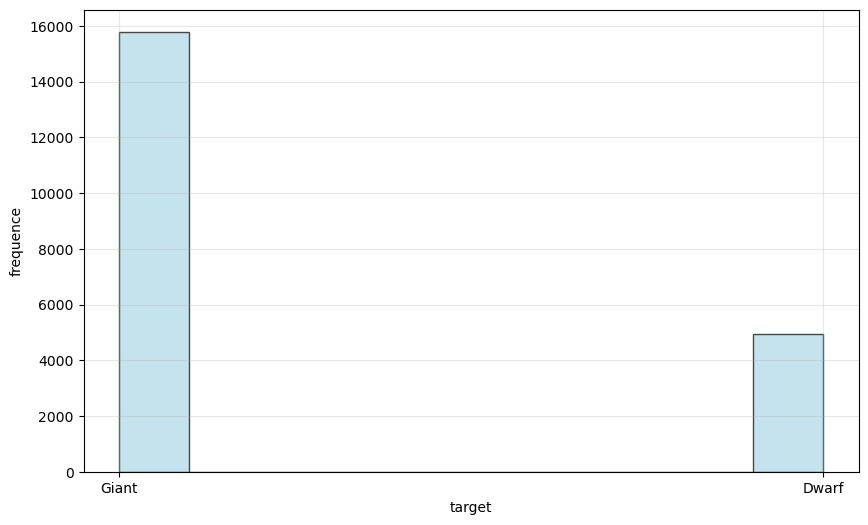

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(train['TargetClass'], alpha=0.7, color='lightblue', edgecolor='black')
plt.xlabel('target')
plt.ylabel('frequence')
plt.grid(True, alpha=0.3)
plt.show()

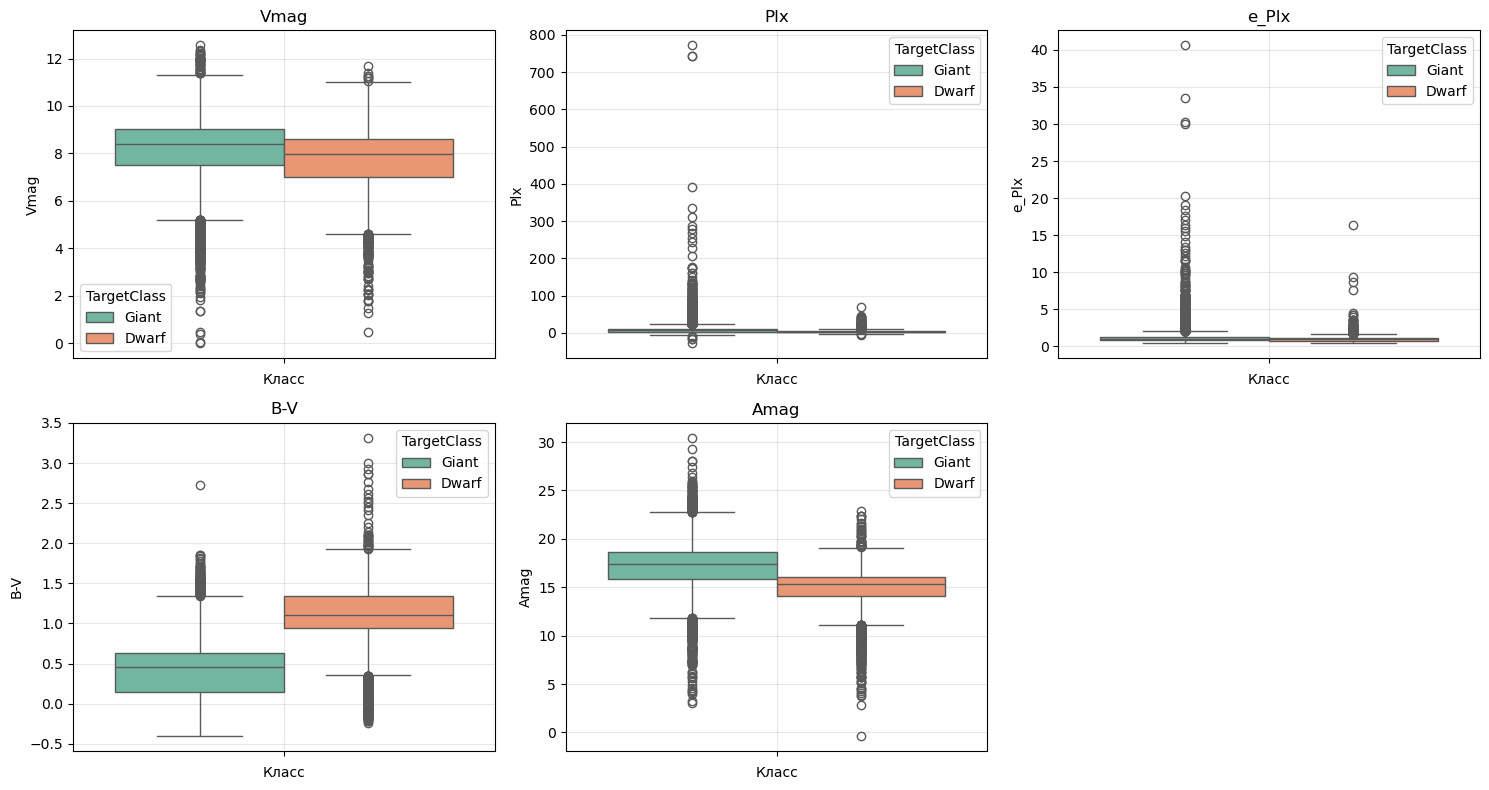

In [7]:
numeric_cols = ['Vmag', 'Plx', 'e_Plx', 'B-V', 'Amag']
plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(hue='TargetClass', y=col, data=train, palette='Set2')
    plt.title(col)
    plt.xlabel('Класс')
    plt.ylabel(col)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

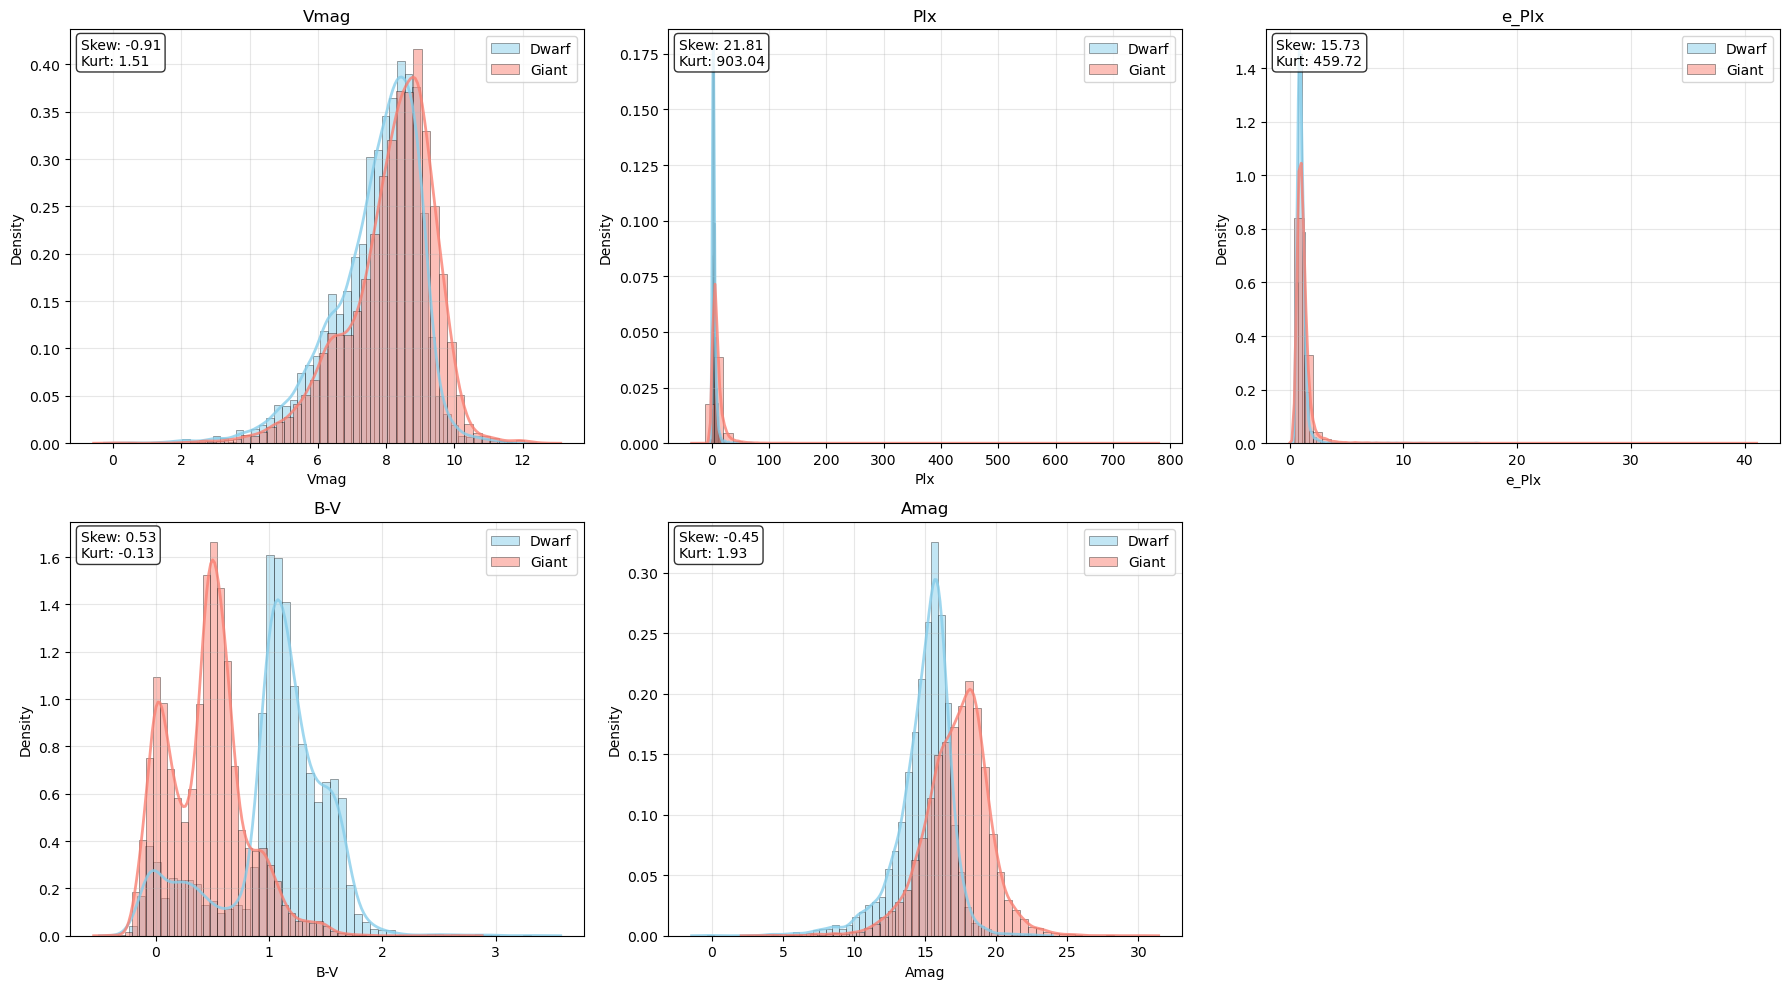

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors = {'Dwarf': 'skyblue', 'Giant': 'salmon'}

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    
    for target_class, color in colors.items():
        subset = train[train['TargetClass'] == target_class][col]
        ax.hist(subset, bins=50, alpha=0.5, label=target_class, 
                color=color, density=True, edgecolor='black', linewidth=0.5)
    
    for target_class, color in colors.items():
        subset = train[train['TargetClass'] == target_class][col]
        sns.kdeplot(subset, ax=ax, color=color, linewidth=2, alpha=0.8)
    
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    stats_text = f"Skew: {train[col].skew():.2f}\nKurt: {train[col].kurtosis():.2f}"
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

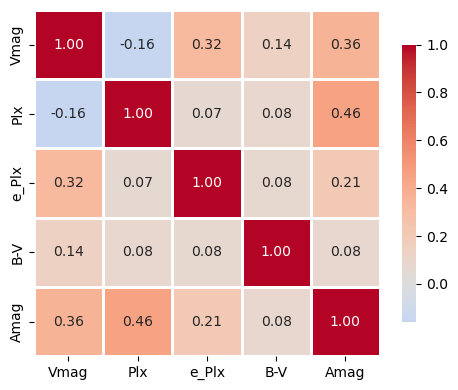

In [9]:
plt.figure(figsize=(5, 4))

correlation_matrix = train[numeric_cols].corr()

heatmap = sns.heatmap(correlation_matrix, 
                      annot=True, 
                      fmt='.2f', 
                      cmap='coolwarm',
                      center=0,
                      square=True,
                      linewidths=1,
                      cbar_kws={"shrink": 0.8},
                      annot_kws={"size": 10})

plt.tight_layout()
plt.show()


In [10]:
def count_outliers_iqr(df):
    outliers_count = {}
    
    for column in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        outliers_count[column] = len(outliers)

    return pd.Series(outliers_count)

outliers_iqr = count_outliers_iqr(train)
print("Количество выбросов по IQR:")
print(sorted(outliers_iqr))

Количество выбросов по IQR:
[33, 472, 592, 1078, 1574]


In [11]:
from sklearn.model_selection import train_test_split

train = train.map(lambda value: {"Giant": 1, "Dwarf": 0}.get(value, value))
test = test.map(lambda value: {"Giant": 1, "Dwarf": 0}.get(value, value))

X = train.drop(columns=['TargetClass'])
y = train['TargetClass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

In [12]:
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train.drop(columns=['SpType']), y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [13]:
y_pred = model.predict(X_test.drop(columns=['SpType']))

f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.4f}")

F1-score: 0.9393


In [14]:
def frequency_encoding(df, column):
    freq = df[column].value_counts(normalize=True)
    return df[column].map(freq)

X_train['cat_feature_freq'] = frequency_encoding(X_train, 'SpType')
X_test['cat_feature_freq'] = frequency_encoding(X_test, 'SpType')

X_train = X_train.drop(columns=['SpType'])
X_test = X_test.drop(columns=['SpType'])

In [15]:
model = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=10000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.4f}")

C:\Users\Vladimir\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


F1-score: 0.9379


In [53]:
test['cat_feature_freq'] = frequency_encoding(test, 'SpType')
test = test.drop(['SpType'], axis=1)
test.head()

,Vmag,Plx,e_Plx,B-V,Amag,cat_feature_freq
0,7.91,6.33,1.01,0.843,16.917019,0.007386
1,7.35,1.30,0.53,1.304,12.919716,0.010043
2,6.75,8.01,0.84,1.019,16.268162,0.068172
3,4.47,7.03,0.72,1.283,13.704777,0.025292
4,7.33,2.45,1.14,1.600,14.275830,0.020563


In [55]:
y_pred = model.predict(test)

submission = pd.DataFrame({
    'index': test.index,
    'TargetClass': y_pred
})

submission.to_csv('stars.csv', index=False)

In [16]:
from sklearn import svm

clf = svm.SVC(kernel='rbf')
clf.fit(X_train, y_train)

y_pred = model.predict(X_test)

f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.4f}")

F1-score: 0.9366


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=1000, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print("=== Random Forest ===")
print(f"F1-score: {f1_score(y_test, y_pred_rf):.4f}")

=== Random Forest ===
F1-score: 0.9402


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    train.drop(columns=["TargetClass"]),
    train["TargetClass"],
    test_size=0.2,
    random_state=42,
)

In [20]:
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

cat_features = ["SpType"]

ohe = OneHotEncoder(
    handle_unknown="ignore"
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", ohe, cat_features)
    ],
    remainder="passthrough"
)

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

In [21]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_enc, y_train)

y_pred = model.predict(X_test_enc)

f1 = f1_score(y_test, y_val_pred)
print(f"F1-score: {f1:.4f}")

NameError: name 'y_val_pred' is not defined

In [ ]:
test_encoded = preprocessor.transform(test)
y_pred = model.predict(test_encoded)

submission = pd.DataFrame({
    'index': test.index,
    'TargetClass': y_pred
})

submission.to_csv('stars.csv', index=False)

In [ ]:
cat_features = ["SpType"]

tar = TargetEncoder()

X_train_tar, X_test_tar = X_train.copy(), X_test.copy()

X_train_tar[cat_features] = tar.fit_transform(
    X_train[cat_features], 
    y_train
)

X_test_tar[cat_features] = tar.transform(
    X_test_tar[cat_features]
)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tar, y_train)

y_pred = model.predict(X_test_tar)

f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.4f}")

In [ ]:
clf = svm.SVC(kernel='rbf')
clf.fit(X_train_tar, y_train)

y_pred = model.predict(X_test_tar)

f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.4f}")

In [ ]:
clf = svm.SVC(kernel='rbf', C=100, class_weight=None, gamma=0.01)
clf.fit(X_train_tar, y_train)

y_pred = model.predict(X_test_tar)

f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.4f}")

In [ ]:
test_encoded = test.copy()
test_encoded[cat_features] = tar.transform(test_encoded[cat_features])

y_pred = model.predict(test_encoded)

submission = pd.DataFrame({
    'index': test.index,
    'TargetClass': y_pred
})

submission.to_csv('stars.csv', index=False)